In [36]:
import pandas as pd
df = pd.read_csv(r'C:\Users\SIDHARTH\Downloads\Main project\books 2.csv')
df.head(5)

,Unnamed: 0,Title,review/helpfulness,review/score,review/summary,review/text
0,0,Night World: Daughters Of Darkness,0.333333,5,best book ever,1 da bst book dat ever read school play im pla...
1,1,Night World: Daughters Of Darkness,0.333333,5,one best night world book,first thought one lj smith best book written a...
2,2,Night World: Daughters Of Darkness,0.333333,3,three sister die,start couldnt put liter didnt stop til id read...
3,3,Night World: Daughters Of Darkness,0.000000,1,disappoint say least,book probabl opinion one worst night world ser...
4,4,Night World: Daughters Of Darkness,0.000000,5,charm captiv work lj smith,plot charact incred everyon like supernatur re...


In [ ]:
df.tail(5)

,Unnamed: 0,Title,review/helpfulness,review/score,review/summary,review/text
1434770,1434770,Jane Eyre,0.208333,1,one star get attent,cant emphas enough great book first book ever ...
1434771,1434771,Jane Eyre,0.117647,1,bore book world,write read book requir english worst book worl...
1434772,1434772,Jane Eyre,0.117647,1,dont wast time,dont understand anybodi could consid enjoy rea...
1434773,1434773,Jane Eyre,0.250000,1,sorri dont like,read literatur paper say book realli dont appr...
1434774,1434774,Jane Eyre,0.066667,1,wrong book,well book good condit wrong book ask certain e...


In [ ]:
df.shape

(1434775, 6)

In [ ]:
df.sample(5)

,Unnamed: 0,Title,review/helpfulness,review/score,review/summary,review/text
687936,687936,The Kitchen Boy: A Novel of the Last Tsar,0.000000,4,review kitchen boy,amaz littl book stori kitchen boy work romanov...
271374,271374,Me Talk Pretty One Day,0.000000,5,fantast funni,ive never come upon book physic made laugh lou...
342177,342177,Understanding Exposure,1.000000,5,everi aspir photograp need book,truli think learn read book one weekend spend ...
860490,860490,"More Guns, Less Crime: Understanding Crime and...",0.346535,1,disappoint,expect someth convinc certainli enough talk bo...
820932,820932,The Greatest Generation,0.454545,1,honor wwii gener read someth els,ive read book first sequel extrem disappoint b...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1434775 entries, 0 to 1434774
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Unnamed: 0          1434775 non-null  int64  
 1   Title               1434775 non-null  object 
 2   review/helpfulness  1434775 non-null  float64
 3   review/score        1434775 non-null  int64  
 4   review/summary      1430823 non-null  object 
 5   review/text         1434763 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 65.7+ MB


In [31]:
df.columns

Index(['review/score', 'review/text'], dtype='object')

Rating Distribution

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


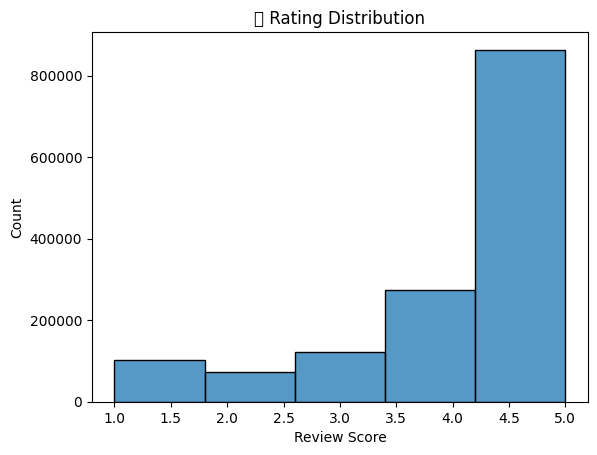

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['review/score'], bins=5)
plt.title("📈 Rating Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


Word Clouds for High vs. Low Ratings

In [16]:
from wordcloud import WordCloud

high_reviews = df[df['review/score'] >= 4]['review/text'].dropna()
low_reviews = df[df['review/score'] <= 2]['review/text'].dropna()

WordCloud(width=800, height=400).generate(" ".join(high_reviews))
WordCloud(width=800, height=400).generate(" ".join(low_reviews))


Sentiment vs. Rating Consistency

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


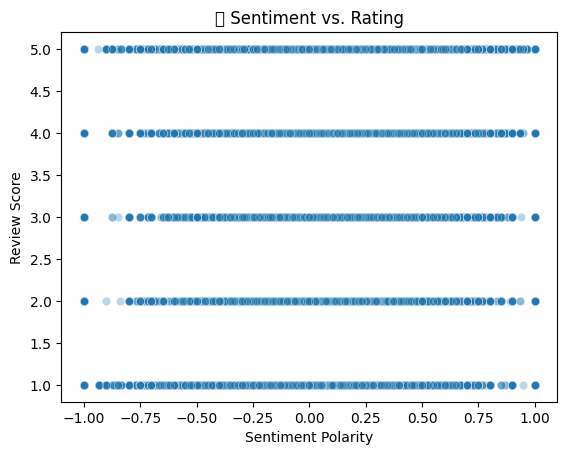

In [17]:
from textblob import TextBlob

df['sentiment'] = df['review/text'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)

sns.scatterplot(data=df, x='sentiment', y='review/score', alpha=0.3)
plt.title("🧠 Sentiment vs. Rating")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Review Score")
plt.show()


Review Length vs. Rating

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


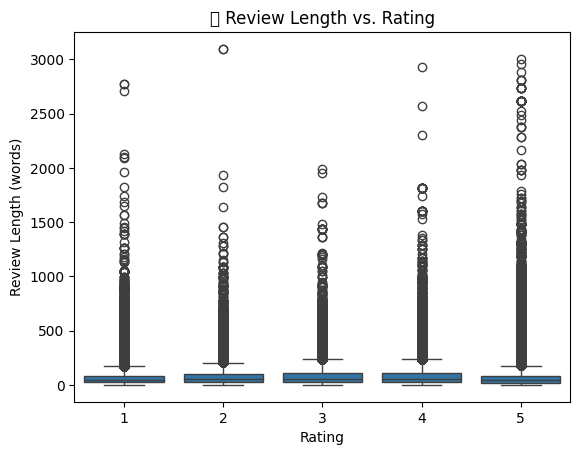

In [18]:
df['length'] = df['review/text'].fillna('').apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='review/score', y='length')
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()


Helpfulness vs. Rating

In [ ]:
pip install boxplot

Note: you may need to restart the kernel to use updated packages.


C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


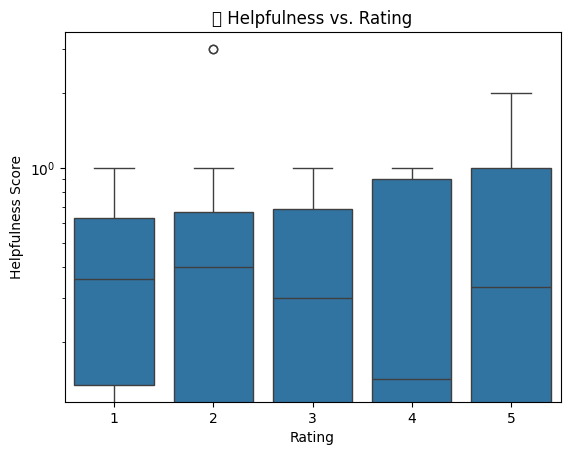

In [37]:
sns.boxplot(data=df, x='review/score', y='review/helpfulness')
plt.title("👍 Helpfulness vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Helpfulness Score")
plt.yscale('log')  # Optional for skewed values
plt.show()


In [38]:
df.drop(columns=['Unnamed: 0', 'Title','review/helpfulness','review/summary', ],inplace=True)

In [ ]:
df.isnull().sum()

,0
review/score,0
review/text,12


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
review/score,0
review/text,0


In [ ]:
df.rename(columns={'review/text':'review','review/score':'rating'},inplace=True)

In [ ]:
df.columns

In [ ]:
df.head(5)

,rating,review
0,5,1 da bst book dat ever read school play im pla...
1,5,first thought one lj smith best book written a...
2,3,start couldnt put liter didnt stop til id read...
3,1,book probabl opinion one worst night world ser...
4,5,plot charact incred everyon like supernatur re...


In [ ]:
print(df.duplicated().sum())

694521


In [ ]:
df.drop_duplicates(subset=['review','rating'],inplace=True)

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df.loc[:, "review"] = df["review"].apply(clean_text)

In [ ]:
df['rating']=df['rating'].astype(int)

In [ ]:
df['rating'].value_counts()

,count
rating,
5,432284
4,140874
3,65120
1,59692
2,42272


In [ ]:
df.shape

(740242, 2)

In [ ]:
df.sample(5)

,rating,review
1050849,2,ambros excel stori fertil ground take book pub...
703116,3,found book interest easi read flow interrupt s...
1332981,1,whether john kerri deserv purpl heart would de...
1333300,5,youv lost anoth custom decid lift ban book bas...
86685,5,let say morn lot work busi today rather diffic...


In [ ]:
df.to_csv('D-BOOKS - 2 DL.csv',index=False)